# Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, f1_score

# Configuration for plots
%matplotlib inline
sns.set(style="whitegrid")

# Load Data and Models

In [2]:
# Load the processed test data and labels
print("Loading data...")
X_test = np.load('X_test_processed.npy')
y_test = np.load('y_test.npy')
class_names = np.load('classes.npy', allow_pickle=True)

# Load the trained models
print("Loading models...")
models = {
    "KNN": joblib.load('knn_model.pkl'),
    "SVM": joblib.load('svm_model.pkl'),
    "Random Forest": joblib.load('rf_model.pkl')
}

print("Data and models loaded successfully.")
print(f"Test Set Shape: {X_test.shape}")
print(f"Classes: {class_names}")

Loading data...
Loading models...
Data and models loaded successfully.
Test Set Shape: (192, 9)
Classes: ['German' 'Italian' 'Korean' 'Spanish']


# Define Evaluation Helper Function

In [3]:
# Dictionary to store metrics for comparison
results = {
    'Model': [],
    'Accuracy': [],
    'F1 Score (Macro)': []
}

def evaluate_model(name, model, X, y):
    """
    Predicts, prints report, updates results dict, and plots confusion matrix.
    """
    print(f"\n{'='*20} Evaluation: {name} {'='*20}")
    
    # Predict
    y_pred = model.predict(X)
    
    # Calculate Metrics
    acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred, average='macro')
    
    # Store results
    results['Model'].append(name)
    results['Accuracy'].append(acc)
    results['F1 Score (Macro)'].append(f1)
    
    # Print Classification Report
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score (Macro): {f1:.4f}\n")
    print("Classification Report:")
    print(classification_report(y, y_pred, target_names=class_names))
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    plt.title(f"Confusion Matrix - {name}")
    plt.grid(False)
    plt.show()

# Evaluate Classification Models


==================== Evaluation: KNN ====================
Accuracy: 0.9948
F1 Score (Macro): 0.9946

Classification Report:
              precision    recall  f1-score   support

      German       1.00      0.98      0.99        42
     Italian       0.98      1.00      0.99        51
      Korean       1.00      1.00      1.00        53
     Spanish       1.00      1.00      1.00        46

    accuracy                           0.99       192
   macro avg       1.00      0.99      0.99       192
weighted avg       0.99      0.99      0.99       192



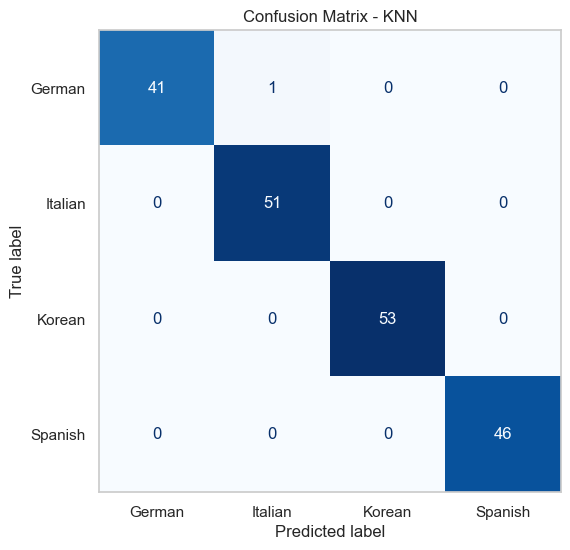


==================== Evaluation: SVM ====================
Accuracy: 0.9896
F1 Score (Macro): 0.9898

Classification Report:
              precision    recall  f1-score   support

      German       1.00      0.98      0.99        42
     Italian       0.96      1.00      0.98        51
      Korean       1.00      0.98      0.99        53
     Spanish       1.00      1.00      1.00        46

    accuracy                           0.99       192
   macro avg       0.99      0.99      0.99       192
weighted avg       0.99      0.99      0.99       192



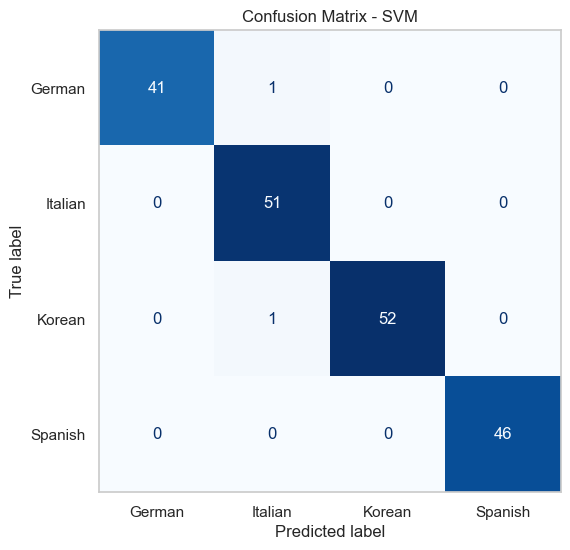


==================== Evaluation: Random Forest ====================
Accuracy: 0.9531
F1 Score (Macro): 0.9530

Classification Report:
              precision    recall  f1-score   support

      German       0.95      0.90      0.93        42
     Italian       0.89      0.98      0.93        51
      Korean       0.98      0.94      0.96        53
     Spanish       1.00      0.98      0.99        46

    accuracy                           0.95       192
   macro avg       0.96      0.95      0.95       192
weighted avg       0.96      0.95      0.95       192



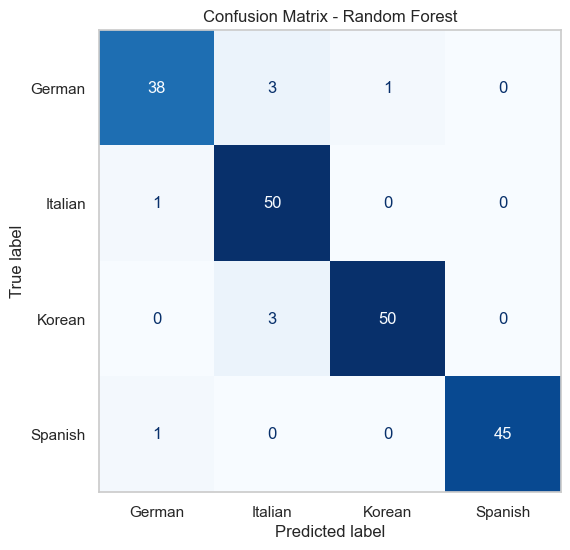

In [4]:
# Iterate through loaded models and evaluate each one
for name, model in models.items():
    evaluate_model(name, model, X_test, y_test)

# Model Comparison Visualization

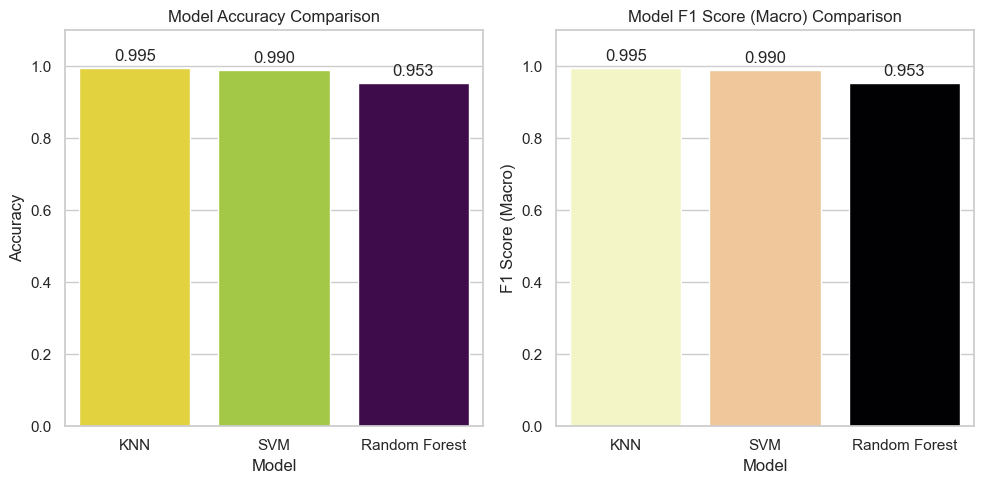

In [9]:
# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Plot Comparison
plt.figure(figsize=(10, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis', hue='Accuracy', legend=False)
plt.ylim(0, 1.1)
plt.title("Model Accuracy Comparison")
for index, row in results_df.iterrows():
    plt.text(index, row.Accuracy + 0.02, f"{row.Accuracy:.3f}", ha='center')

# Plot F1 Score
plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='F1 Score (Macro)', data=results_df, palette='magma', hue='F1 Score (Macro)', legend=False)
plt.ylim(0, 1.1)
plt.title("Model F1 Score (Macro) Comparison")
for index, row in results_df.iterrows():
    plt.text(index, row['F1 Score (Macro)'] + 0.02, f"{row['F1 Score (Macro)']:.3f}", ha='center')

plt.tight_layout()
plt.show()

# Clustering Evaluation

Report **Silhouette Score** and **Cluster Purity** / composition of each cluster (as per project requirements).

       CLUSTERING EVALUATION

--- Silhouette Score ---
K-Means (k=4):        0.2733
Agglomerative (k=4):  0.2547

--- Cluster Purity & Composition (K-Means) ---
  Cluster 0: n=269, purity=0.520, majority=Korean | German: 128, Italian: 1, Korean: 140, Spanish: 0
  Cluster 1: n=154, purity=0.584, majority=Spanish | German: 1, Italian: 62, Korean: 1, Spanish: 90
  Cluster 2: n=199, purity=0.588, majority=Italian | German: 43, Italian: 117, Korean: 39, Spanish: 0
  Cluster 3: n=90, purity=1.000, majority=Spanish | German: 0, Italian: 0, Korean: 0, Spanish: 90
  Overall cluster purity: 0.6138

--- Cluster Purity & Composition (Agglomerative) ---
  Cluster 0: n=239, purity=0.418, majority=Italian | German: 49, Italian: 100, Korean: 0, Spanish: 90
  Cluster 1: n=150, purity=0.533, majority=Italian | German: 40, Italian: 80, Korean: 30, Spanish: 0
  Cluster 2: n=233, purity=0.644, majority=Korean | German: 83, Italian: 0, Korean: 150, Spanish: 0
  Cluster 3: n=90, purity=1.000, majority=Spanis

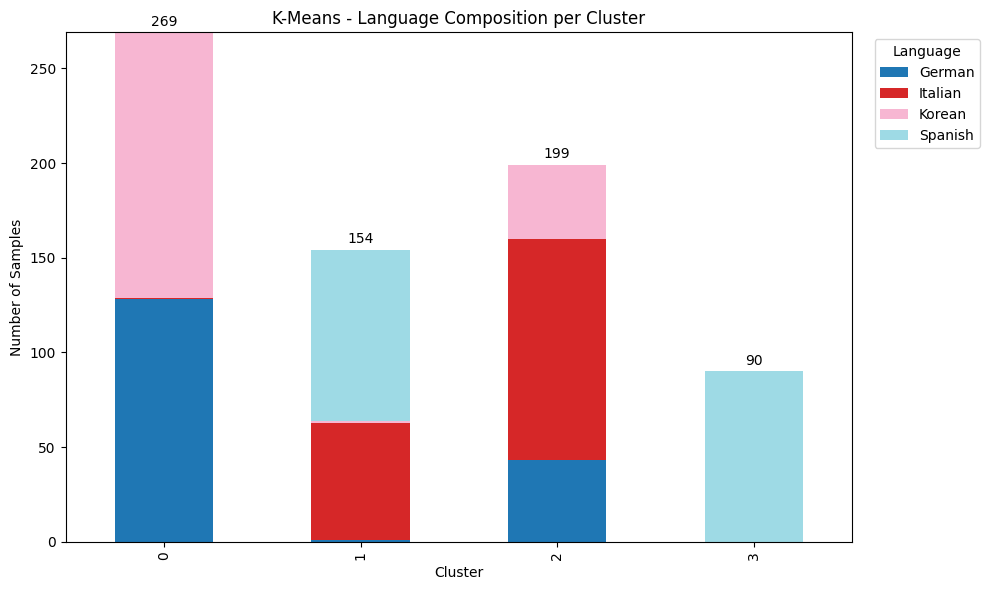

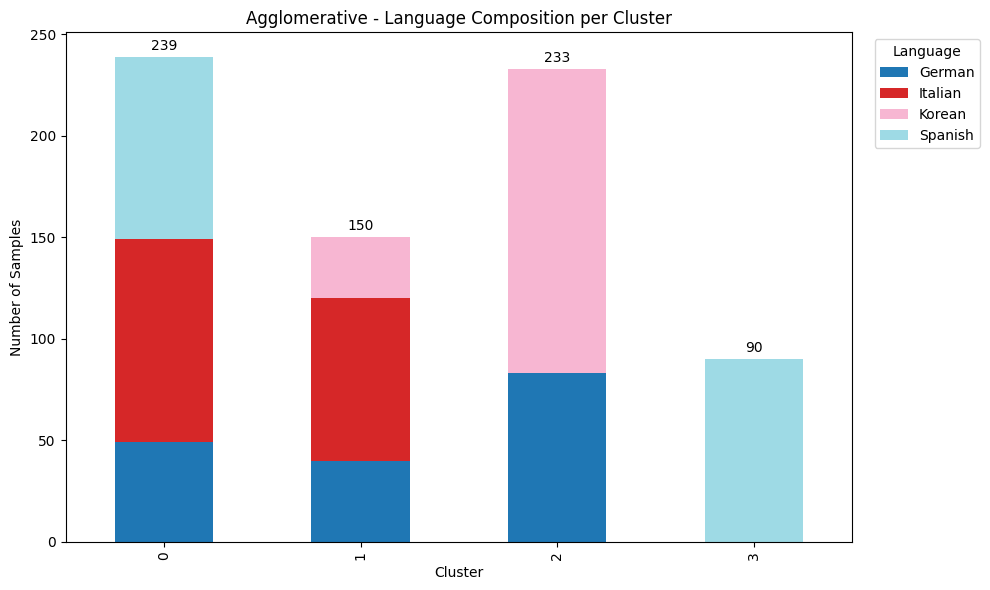

In [2]:
print("="*40)
print("       CLUSTERING EVALUATION")
print("="*40)

# Load clustering results exported from clustering.ipynb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

data = np.load("clustering_export.npz", allow_pickle=True)
cluster_labels_kmeans = data["cluster_labels_kmeans"]
cluster_labels_agg = data["cluster_labels_agg"]
y_true = data["y_true"]
sil_kmeans = float(data["silhouette_kmeans"])
sil_agg = float(data["silhouette_agg"])
n_clusters = int(data["n_clusters"])

# --- 1. Report Silhouette Score (as per ML2025FinalProject 95-97) ---
print("\n--- Silhouette Score ---")
print(f"K-Means (k={n_clusters}):        {sil_kmeans:.4f}")
print(f"Agglomerative (k={n_clusters}):  {sil_agg:.4f}")

def cluster_purity_and_composition(cluster_labels, y_true, method_name):
    """Compute overall purity and per-cluster composition (counts by true label)."""
    y_true = np.asarray(y_true)
    unique_true = np.unique(y_true)
    unique_clusters = np.unique(cluster_labels)
    n = len(y_true)
    correct = 0
    print(f"\n--- Cluster Purity & Composition ({method_name}) ---")
    for c in unique_clusters:
        mask = cluster_labels == c
        size = mask.sum()
        counts = {}
        for lang in unique_true:
            counts[lang] = np.sum(y_true[mask] == lang)
        majority_count = max(counts.values())
        majority_lang = max(counts, key=counts.get)
        purity_c = majority_count / size if size else 0
        correct += majority_count
        comp = ", ".join(f"{lang}: {counts[lang]}" for lang in unique_true)
        print(f"  Cluster {c}: n={size}, purity={purity_c:.3f}, majority={majority_lang} | {comp}")
    overall_purity = correct / n if n else 0
    print(f"  Overall cluster purity: {overall_purity:.4f}")
    return overall_purity

def build_composition_df(cluster_labels, y_true):
    """Build a cluster x language count table."""
    return pd.crosstab(
        pd.Series(cluster_labels, name="Cluster"),
        pd.Series(y_true, name="Language")
    ).sort_index()

def plot_cluster_composition_stacked(composition_df, method_name):
    """Plot stacked bar chart of language composition for each cluster."""
    ax = composition_df.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 6),
        colormap="tab20"
    )
    ax.set_title(f"{method_name} - Language Composition per Cluster")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Number of Samples")
    ax.legend(title="Language", bbox_to_anchor=(1.02, 1), loc="upper left")

    # Add total sample count above each stacked bar.
    totals = composition_df.sum(axis=1)
    y_offset = max(1, int(totals.max() * 0.01))
    for idx, total in enumerate(totals):
        ax.text(idx, total + y_offset, str(int(total)), ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.show()

# --- 2. Analyze Cluster Purity and composition of each cluster ---
purity_kmeans = cluster_purity_and_composition(cluster_labels_kmeans, y_true, "K-Means")
purity_agg = cluster_purity_and_composition(cluster_labels_agg, y_true, "Agglomerative")

# --- 3. Plot stacked bar charts for language composition by cluster ---
comp_kmeans = build_composition_df(cluster_labels_kmeans, y_true)
comp_agg = build_composition_df(cluster_labels_agg, y_true)

print("\n--- Plotting Cluster Composition (Stacked Bar) ---")
plot_cluster_composition_stacked(comp_kmeans, "K-Means")
plot_cluster_composition_stacked(comp_agg, "Agglomerative")